In [2]:
# import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# load dataset
df = pd.read_csv("assessor_rm_sli_merged.csv", low_memory=False)
print("initial rows:", len(df))

# filter for confirmed and suspected rows
# confirmed = LEAD or NOT LEAD in both private and public service lines
# suspected = SUSPECTED LEAD in either private or public service lines
confirmed_mask = df["Private Service Line Material"].isin(["LEAD", "NOT LEAD"]) & \
                 df["Public Service Line Material"].isin(["LEAD", "NOT LEAD"])
suspected_mask = (df["Private Service Line Material"] == "SUSPECTED LEAD") | \
                 (df["Public Service Line Material"] == "SUSPECTED LEAD")

# create confirmed and suspected dataframes
confirmed_df = df[confirmed_mask].copy()
suspected_df = df[suspected_mask].copy()

print("confirmed rows:", len(confirmed_df))
print("suspected rows:", len(suspected_df))

# columns to drop (either duplicates, too many missing values, or irrelevant)
drop_cols = [
    "Assessment Triad", "FEMA Floodplain", "geoposition", "Sale Price",
    "Garage 1 Area", "property_city", "municipality", "ssa_name", "ssa_no",
    "ohare_noise", "floodplain", "fs_flood_risk_direction", "withinmr100", "withinmr101300",
    "indicator_has_latlon", "Cleaned Address", "Address", "property_address",
    "property_zip", "tract_geoid", "tax_rate", "tract-Midincome", "township", "nbhd", "Apartments"
]

confirmed_df.drop(columns=drop_cols, errors="ignore", inplace=True)
suspected_df.drop(columns=drop_cols, errors="ignore", inplace=True)

# save property address before dropping from features
confirmed_df["RowID"] = confirmed_df.index
suspected_df["RowID"] = suspected_df.index

# feature columns (exclude targets and address info)
feature_cols = [col for col in confirmed_df.columns if col not in [
    "Private Service Line Material", "Public Service Line Material", "RowID", "Property Address"]]

# encode categorical features using label encoding
categorical_cols = confirmed_df[feature_cols].select_dtypes(include="object").columns.tolist()
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    full_col = pd.concat([confirmed_df[col], suspected_df[col]], axis=0).astype(str) # fit on both datasets
    le.fit(full_col)
    confirmed_df[col] = le.transform(confirmed_df[col].astype(str))
    suspected_df[col] = le.transform(suspected_df[col].astype(str))
    encoders[col] = le

# fill numerical columns (empty values with median)
numerical_cols = confirmed_df[feature_cols].select_dtypes(include=["float64", "int64"]).columns.tolist()
for col in numerical_cols:
    median = confirmed_df[col].median()
    confirmed_df[col] = confirmed_df[col].fillna(median)
    suspected_df[col] = suspected_df[col].fillna(median)

initial rows: 392196
confirmed rows: 49385
suspected rows: 340551


In [3]:
# extract features and standardize (necessary for k-NN)
X_confirmed = confirmed_df[feature_cols].copy()
X_suspected = suspected_df[feature_cols].copy()
scaler = StandardScaler()
X_confirmed_scaled = scaler.fit_transform(X_confirmed)
X_suspected_scaled = scaler.transform(X_suspected)

# k-NN on private line
y_confirmed_private = confirmed_df["Private Service Line Material"].replace({"LEAD": 1, "NOT LEAD": 0})
knn_private = KNeighborsClassifier(n_neighbors=100)
knn_private.fit(X_confirmed_scaled, y_confirmed_private)
proba_private = knn_private.predict_proba(X_suspected_scaled) # predict probabilities (the vote of the k-nearest neighbors)
lead_probs_private = proba_private[:, 1] # probability of being LEAD
uncertainty_private = 1 - np.abs(lead_probs_private - 0.5) * 2 # if 50-50 vote: uncertainty = 1, if 100-0 or 0-100 vote: uncertainty = 0

# k-NN on public line
y_confirmed_public = confirmed_df["Public Service Line Material"].replace({"LEAD": 1, "NOT LEAD": 0})
knn_public = KNeighborsClassifier(n_neighbors=100)
knn_public.fit(X_confirmed_scaled, y_confirmed_public)
proba_public = knn_public.predict_proba(X_suspected_scaled)
lead_probs_public = proba_public[:, 1]
uncertainty_public = 1 - np.abs(lead_probs_public - 0.5) * 2

# attach uncertainty columns
suspected_df = suspected_df.copy()
suspected_df["Uncertainty_Private"] = uncertainty_private
suspected_df["Uncertainty_Public"] = uncertainty_public

def combined_score(row):
    priv_unknown = row["Private Service Line Material"] == "SUSPECTED LEAD"
    pub_unknown = row["Public Service Line Material"] == "SUSPECTED LEAD"
    if priv_unknown and pub_unknown:
        return row["Uncertainty_Private"] * row["Uncertainty_Public"] # prioritize uncertainty in both
    elif priv_unknown:
        return row["Uncertainty_Private"] * 0.5
    elif pub_unknown:
        return row["Uncertainty_Public"] * 0.5
    return 0

suspected_df["Combined_Uncertainty"] = suspected_df.apply(combined_score, axis=1) # assign combined uncertainty score to each row

C:\Users\nerdi\AppData\Local\Temp\ipykernel_17592\2153164535.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_confirmed_private = confirmed_df["Private Service Line Material"].replace({"LEAD": 1, "NOT LEAD": 0})
C:\Users\nerdi\AppData\Local\Temp\ipykernel_17592\2153164535.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_confirmed_public = confirmed_df["Public Service Line Material"].replace({"LEAD": 1, "NOT LEAD": 0})


In [4]:
# sort and cluster top uncertain rows
most_uncertain_combined = suspected_df.sort_values("Combined_Uncertainty", ascending=False).head(200)

# filter scaled features for the selected rows
top_indices = most_uncertain_combined.index
X_top_combined = X_suspected_scaled[top_indices.get_indexer_for(top_indices)]

# determine optimal number of clusters using silhouette score
# the number of clustesr we want might change each time we rerun, we could also do this manually
best_k = 2
best_score = -1
for k in range(3, min(25, len(X_top_combined))):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_top_combined)
    score = silhouette_score(X_top_combined, labels)
    print(f"silhouette score for k={k}: {score:.4f}")
    if score > best_score:
        best_score = score
        best_k = k

# run k-means with optimal k
kmeans = KMeans(n_clusters=best_k, random_state=42)
cluster_labels = kmeans.fit_predict(X_top_combined)
most_uncertain_combined = most_uncertain_combined.copy()
most_uncertain_combined["Cluster"] = cluster_labels

# find representative addresses for each cluster
representatives = []
for i in range(best_k):
    cluster_rows = most_uncertain_combined[most_uncertain_combined["Cluster"] == i]
    cluster_feats = X_suspected_scaled[cluster_rows.index.get_indexer_for(cluster_rows.index)]

    # get the cluster center, distance from all points to center, and pick the closest one
    center = kmeans.cluster_centers_[i]
    dists = np.linalg.norm(cluster_feats - center, axis=1)
    closest_idx = cluster_rows.index[np.argmin(dists)]
    representatives.append(closest_idx)


# display results
selected_rows = suspected_df.loc[representatives][[
    "RowID", "Property Address", "Private Service Line Material", "Public Service Line Material",
    "Uncertainty_Private", "Uncertainty_Public", "Combined_Uncertainty"
]]
print(f"\nselected {len(selected_rows)} representative rows for testing:")
print(selected_rows)


silhouette score for k=3: 0.1774
silhouette score for k=4: 0.1116
silhouette score for k=5: 0.1295
silhouette score for k=6: 0.1336
silhouette score for k=7: 0.1078
silhouette score for k=8: 0.1215
silhouette score for k=9: 0.1288
silhouette score for k=10: 0.1170
silhouette score for k=11: 0.1168
silhouette score for k=12: 0.0993
silhouette score for k=13: 0.1085
silhouette score for k=14: 0.1157
silhouette score for k=15: 0.1245
silhouette score for k=16: 0.1295
silhouette score for k=17: 0.1274
silhouette score for k=18: 0.1254
silhouette score for k=19: 0.1133
silhouette score for k=20: 0.1124
silhouette score for k=21: 0.1214
silhouette score for k=22: 0.1260
silhouette score for k=23: 0.1268
silhouette score for k=24: 0.1307

selected 3 representative rows for testing:
         RowID    Property Address Private Service Line Material  \
367352  367352   8626 S KEELER AVE                SUSPECTED LEAD   
160559  160559   3613 S WALLACE ST                SUSPECTED LEAD   
353733  35

c:\tools\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\tools\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\tools\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\tools\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there a

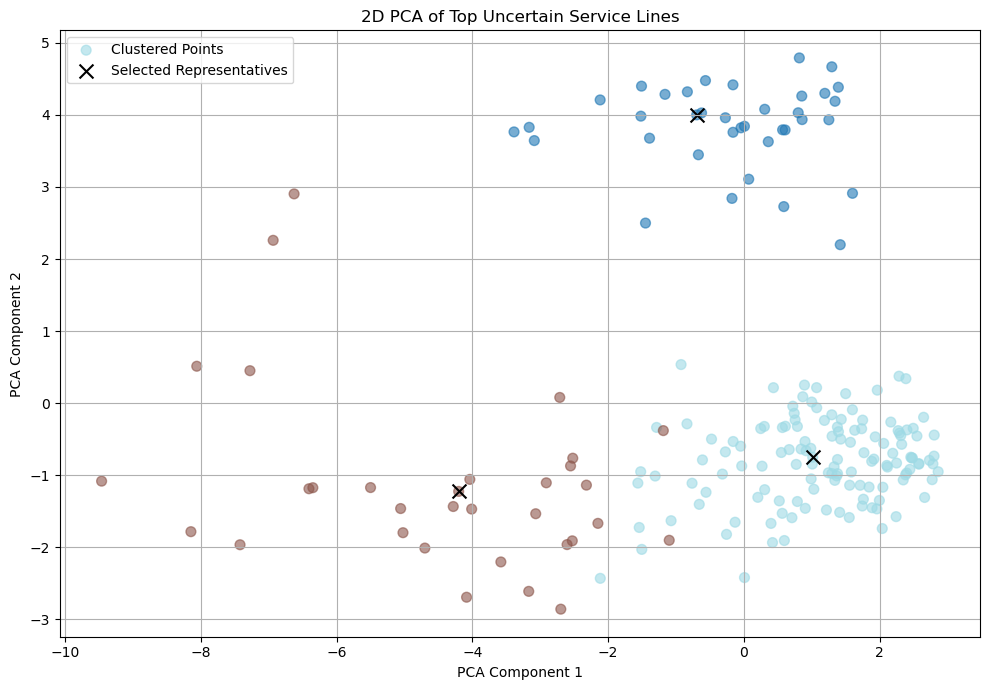


selected addresses for service line composition testing:
- 8626 S KEELER AVE
- 3613 S WALLACE ST
- 8150 S KILDARE AVE


In [5]:
# visualize clusters using pca
pca = PCA(n_components=2)
X_top_2d = pca.fit_transform(X_top_combined)
most_uncertain_combined = most_uncertain_combined.copy()
most_uncertain_combined["PCA1"] = X_top_2d[:, 0]
most_uncertain_combined["PCA2"] = X_top_2d[:, 1]
most_uncertain_combined["Is_Representative"] = most_uncertain_combined.index.isin(representatives)

plt.figure(figsize=(10, 7))
plt.scatter(
    most_uncertain_combined["PCA1"],
    most_uncertain_combined["PCA2"],
    c=most_uncertain_combined["Cluster"],
    cmap="tab20",
    s=50,
    alpha=0.6,
    label="Clustered Points"
)
plt.scatter(
    most_uncertain_combined.loc[most_uncertain_combined["Is_Representative"], "PCA1"],
    most_uncertain_combined.loc[most_uncertain_combined["Is_Representative"], "PCA2"],
    color="black",
    marker="x",
    s=100,
    label="Selected Representatives"
)
plt.title("2D PCA of Top Uncertain Service Lines")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nselected addresses for service line composition testing:")
for addr in suspected_df.loc[representatives]["Property Address"]:
    print("-", addr)


In [ ]:
# select top 200 most uncertain rows
top_200 = suspected_df.sort_values("Combined_Uncertainty", ascending=False).head(200)

# select columns to include in the file
cols_to_save = [
    "Property Address", 
    "Private Service Line Material", 
    "Public Service Line Material",
    "Uncertainty_Private", 
    "Uncertainty_Public", 
    "Combined_Uncertainty"
]

# write to a text file
with open("top_200_addresses.txt", "w") as f:
    for _, row in top_200[cols_to_save].iterrows():
        f.write(
            f"Address: {row['Property Address']}\n"
            f"  Private Line: {row['Private Service Line Material']} (Uncertainty: {row['Uncertainty_Private']:.3f})\n"
            f"  Public Line:  {row['Public Service Line Material']} (Uncertainty: {row['Uncertainty_Public']:.3f})\n"
            f"  Combined Uncertainty: {row['Combined_Uncertainty']:.3f}\n"
            f"{'-'*50}\n"
        )

print("saved detailed info for top 200 rows to 'top_200_addresses.txt'")


saved detailed info for top 200 rows to 'top_200_addresses.txt'
